In [2]:
import pandas as pd
import numpy as np
data = pd.read_csv('water1.csv')


data.replace('?', np.nan, inplace= True)
data = data.astype({"OBS_VALUE": np.float64, "TIME_PERIOD": np.float64})

In [3]:
import pandas as pd

df = pd.read_csv('water1.csv')

# Basic inspection
print(df.shape)          # rows and columns
print(df.dtypes)         # data types
print(df.head())         # first 5 rows
print(df.describe())     # summary stats
print(df.isnull().sum()) # missing values

(414, 39)
STRUCTURE                     str
STRUCTURE_ID                  str
ACTION                        str
FREQ                          str
FREQ_LABEL                    str
REF_AREA                      str
REF_AREA_LABEL                str
INDICATOR                     str
INDICATOR_LABEL               str
SEX                           str
SEX_LABEL                     str
AGE                           str
AGE_LABEL                     str
URBANISATION                  str
URBANISATION_LABEL            str
UNIT_MEASURE                  str
UNIT_MEASURE_LABEL            str
COMP_BREAKDOWN_1              str
COMP_BREAKDOWN_1_LABEL        str
COMP_BREAKDOWN_2              str
COMP_BREAKDOWN_2_LABEL        str
COMP_BREAKDOWN_3              str
COMP_BREAKDOWN_3_LABEL        str
TIME_PERIOD                 int64
OBS_VALUE                 float64
AGG_METHOD                    str
AGG_METHOD_LABEL              str
DATABASE_ID                   str
DATABASE_ID_LABEL             str
UNIT

In [4]:
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'COMP_BREAKDOWN_1_LABEL']].copy()

# Rename for readability
df_clean.columns = ['country', 'year', 'water_pct', 'sector']

print(df_clean.head())

               country  year  water_pct                       sector
0          Afghanistan  2025  13.969929  Sector: Manufacturing - All
1              Albania  2025  16.635416  Sector: Manufacturing - All
2               Angola  2024  21.268438  Sector: Manufacturing - All
3  Antigua and Barbuda  2025  25.898235  Sector: Manufacturing - All
4            Argentina  2026   8.944803  Sector: Manufacturing - All


In [5]:
# Global summary
print(df_clean['water_pct'].describe())

# Average by country (only "All" sector to avoid duplicates)
df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All']

country_avg = df_all.groupby('country')['water_pct'].mean().sort_values(ascending=False)
print(country_avg.head(10))  # top 10 worst countries

count    414.000000
mean      10.564384
std       13.762779
min        0.000000
25%        0.908888
50%        5.549607
75%       15.100742
max       77.280388
Name: water_pct, dtype: float64
country
Burundi               77.280388
Malawi                74.091087
St. Lucia             60.544182
Ethiopia              54.664181
Iraq                  46.542591
Dominican Republic    45.643723
Mauritania            44.360054
Solomon Islands       44.267704
Guinea-Bissau         43.997421
Gambia, The           42.198452
Name: water_pct, dtype: float64


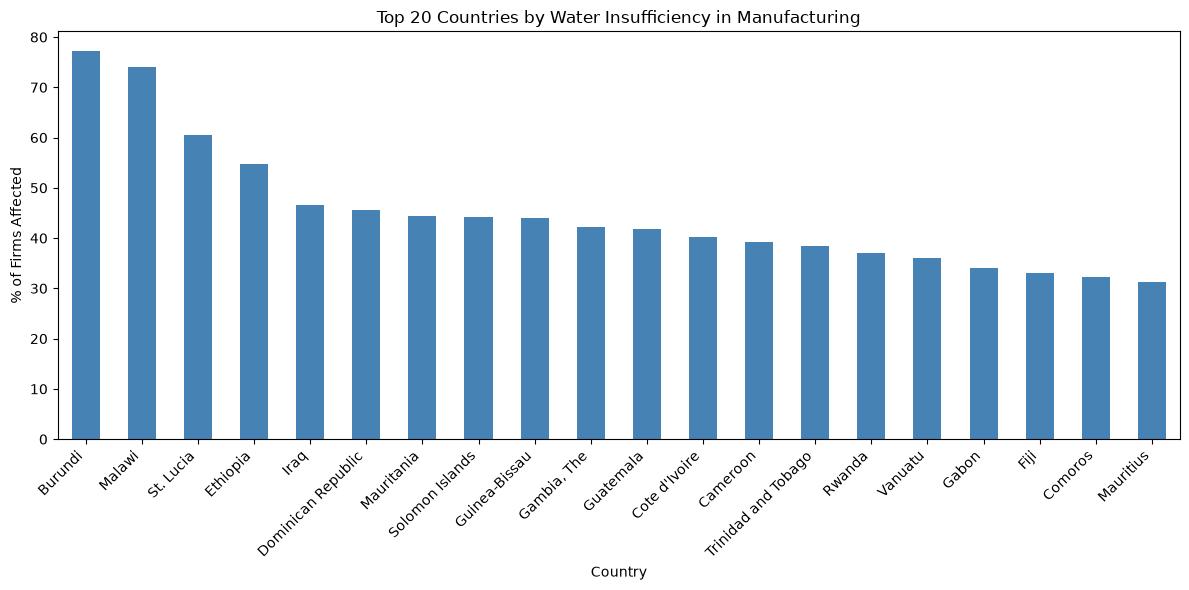

In [6]:
import matplotlib.pyplot as plt

top20 = country_avg.head(20)

plt.figure(figsize=(12, 6))
top20.plot(kind='bar', color='steelblue')
plt.title('Top 20 Countries by Water Insufficiency in Manufacturing')
plt.ylabel('% of Firms Affected')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top20_countries.png')
plt.show()

In [7]:
# Global summary
print(df_clean['water_pct'].describe())

# Average by country (only "All" sector to avoid duplicates)
df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All']

country_avg = df_all.groupby('country')['water_pct'].mean().sort_values(ascending=False)
print(country_avg.head(20))  # top 10 worst countries

count    414.000000
mean      10.564384
std       13.762779
min        0.000000
25%        0.908888
50%        5.549607
75%       15.100742
max       77.280388
Name: water_pct, dtype: float64
country
Burundi                77.280388
Malawi                 74.091087
St. Lucia              60.544182
Ethiopia               54.664181
Iraq                   46.542591
Dominican Republic     45.643723
Mauritania             44.360054
Solomon Islands        44.267704
Guinea-Bissau          43.997421
Gambia, The            42.198452
Guatemala              41.880859
Cote d'Ivoire          40.194168
Cameroon               39.327271
Trinidad and Tobago    38.443069
Rwanda                 37.111542
Vanuatu                35.969101
Gabon                  34.130081
Fiji                   33.123817
Comoros                32.320606
Mauritius              31.182619
Name: water_pct, dtype: float64


In [8]:
# Average by country (only "All" sector to avoid duplicates)
df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All']

country_avg = df_all.groupby('country')['water_pct'].mean().sort_values(ascending=True)
print(country_avg.head(20))  # top 10 BEST countries

country
Saudi Arabia      0.000000
Qatar             0.000000
Lithuania         0.000000
Singapore         0.000000
Tonga             0.000000
Japan             0.025599
Cambodia          0.030784
Korea, Rep.       0.091301
Poland            0.131697
United Kingdom    0.146963
Slovenia          0.152889
France            0.190136
Belgium           0.375516
New Zealand       0.399949
Nigeria           0.476887
Netherlands       0.494566
Indonesia         0.544864
Austria           0.642493
Canada            0.679398
Guinea            0.682090
Name: water_pct, dtype: float64


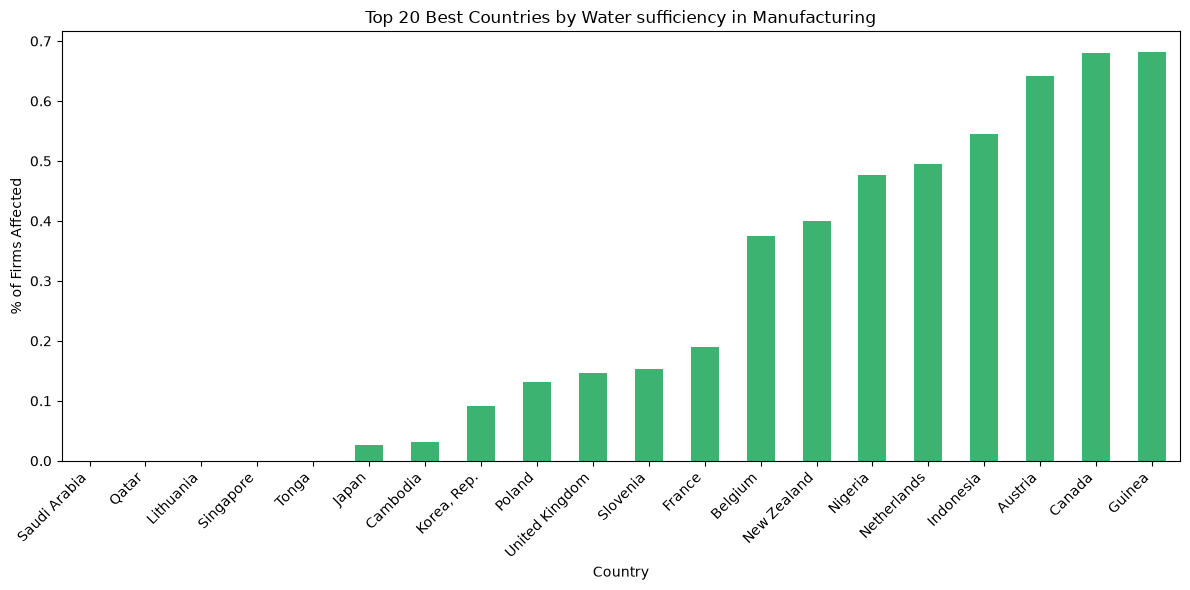

In [9]:
import matplotlib.pyplot as plt

top10_best = country_avg.head(20)

plt.figure(figsize=(12, 6))
top10_best.plot(kind='bar', color='mediumseagreen')
plt.title('Top 20 Best Countries by Water sufficiency in Manufacturing')
plt.ylabel('% of Firms Affected')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top10_best_countries.png')
plt.show()

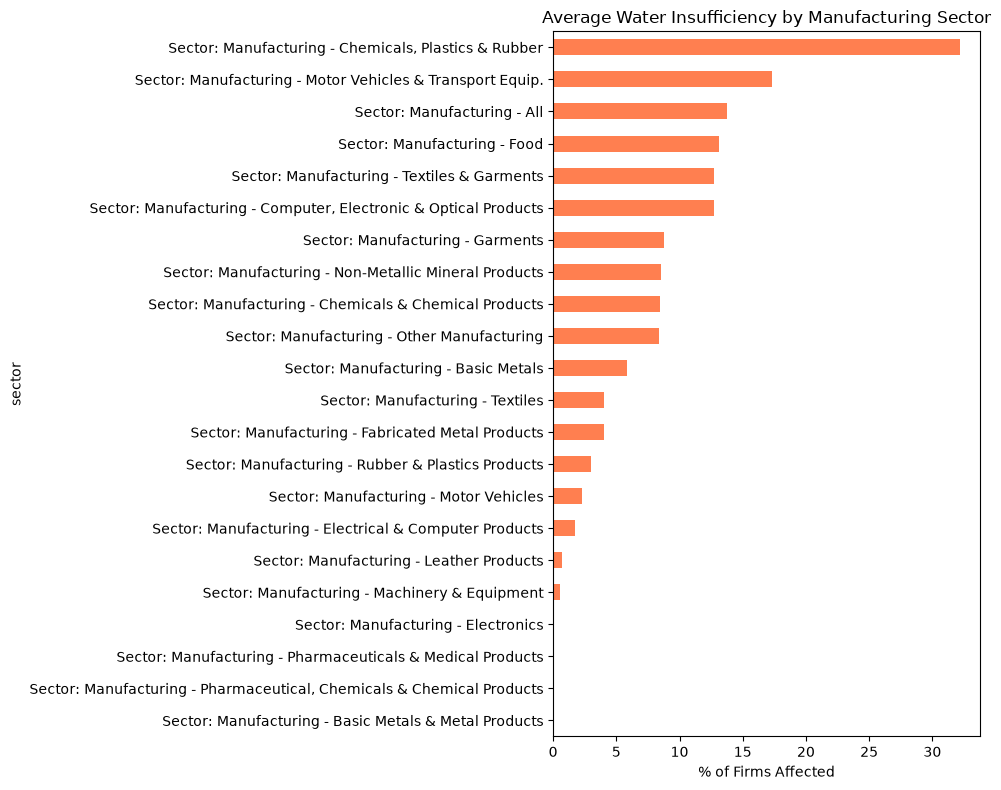

In [10]:
sector_avg = df_clean.groupby('sector')['water_pct'].mean().sort_values()

plt.figure(figsize=(10, 8))
sector_avg.plot(kind='barh', color='coral')
plt.title('Average Water Insufficiency by Manufacturing Sector')
plt.xlabel('% of Firms Affected')
plt.tight_layout()
plt.savefig('sector_comparison.png')
plt.show()

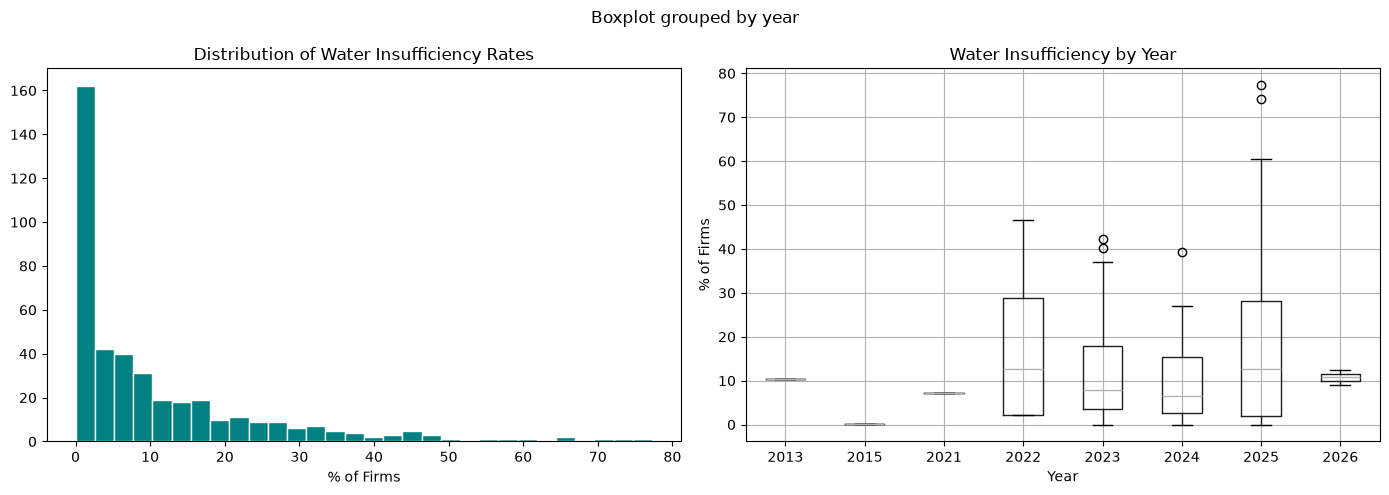

In [11]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['water_pct'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Water Insufficiency Rates')
axes[0].set_xlabel('% of Firms')

# Boxplot by year
df_all.boxplot(column='water_pct', by='year', ax=axes[1])
axes[1].set_title('Water Insufficiency by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Firms')

plt.tight_layout()
plt.savefig('distribution.png')
plt.show()

In [17]:
Q1 = df_clean['water_pct'].quantile(0.25)
Q3 = df_clean['water_pct'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_clean[df_clean['water_pct'] > Q3 + 1.5 * IQR]
print(f"Outliers found: {len(outliers)}")
print(outliers[['country', 'year', 'water_pct']].sort_values('water_pct', ascending=False))

Outliers found: 25
                 country  year  water_pct
47               Burundi  2025  77.280388
233               Malawi  2025  74.091087
106             Ethiopia  2025  71.759842
181                 Iraq  2022  66.927917
53              Cameroon  2024  66.639290
350            St. Lucia  2025  60.544182
79         Cote d'Ivoire  2023  58.102093
105             Ethiopia  2025  54.664181
107             Ethiopia  2025  49.776962
108             Ethiopia  2025  46.794456
384               Uganda  2025  46.763615
179                 Iraq  2022  46.542591
89    Dominican Republic  2025  45.643723
210                Kenya  2025  45.286545
242           Mauritania  2025  44.360054
339      Solomon Islands  2025  44.267704
139        Guinea-Bissau  2025  43.997421
119          Gambia, The  2023  42.198452
231           Madagascar  2022  42.122627
138            Guatemala  2025  41.880859
78         Cote d'Ivoire  2023  40.194168
52              Cameroon  2024  39.327271
371  Trinidad a

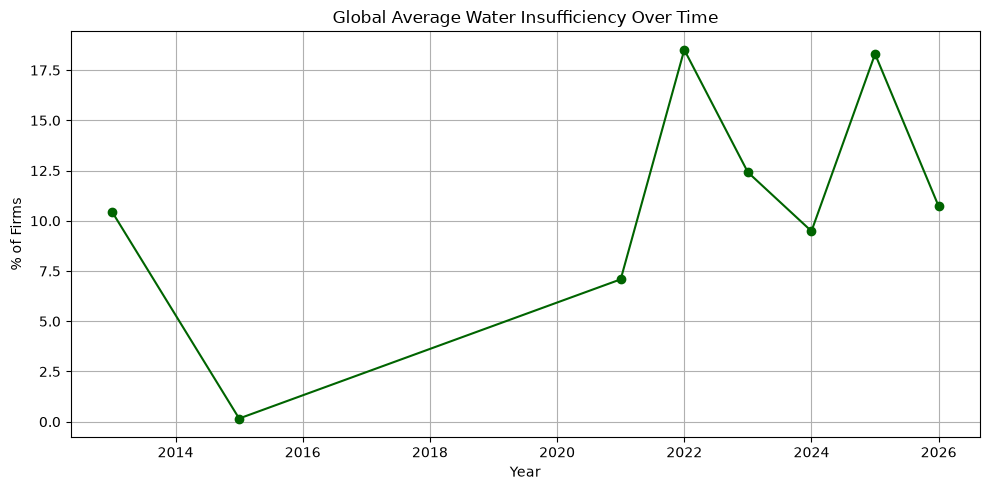

In [12]:
yearly_avg = df_all.groupby('year')['water_pct'].mean()

plt.figure(figsize=(10, 5))
yearly_avg.plot(marker='o', color='darkgreen')
plt.title('Global Average Water Insufficiency Over Time')
plt.ylabel('% of Firms')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.savefig('time_trend.png')
plt.show()

In [13]:
pip install scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean
df = pd.read_csv('water1.csv')
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 
                'COMP_BREAKDOWN_1_LABEL']].copy()
df_clean.columns = ['country', 'year', 'water_pct', 'sector']

# Filter to all-manufacturing only to keep it clean
df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All']

In [15]:
# Convert country names to numeric codes
df_all = df_all.copy()
df_all['country_code'] = df_all['country'].astype('category').cat.codes

# Features (what we use to predict) and Target (what we predict)
X = df_all[['year', 'country_code']]  # inputs
y = df_all['water_pct']               # output to predict

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (164, 2)
Target shape: (164,)


In [16]:
# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 131
Testing rows:  33


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Year coefficient:    {model.coef_[0]:.4f}")
print(f"Country coefficient: {model.coef_[1]:.4f}")
print(f"Intercept:           {model.intercept_:.4f}")

Model trained successfully!
Year coefficient:    1.2042
Country coefficient: -0.0135
Intercept:           -2422.2427


In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"R² Score:                  {r2:.4f}")

Mean Absolute Error (MAE): 10.37%
R² Score:                  0.0399


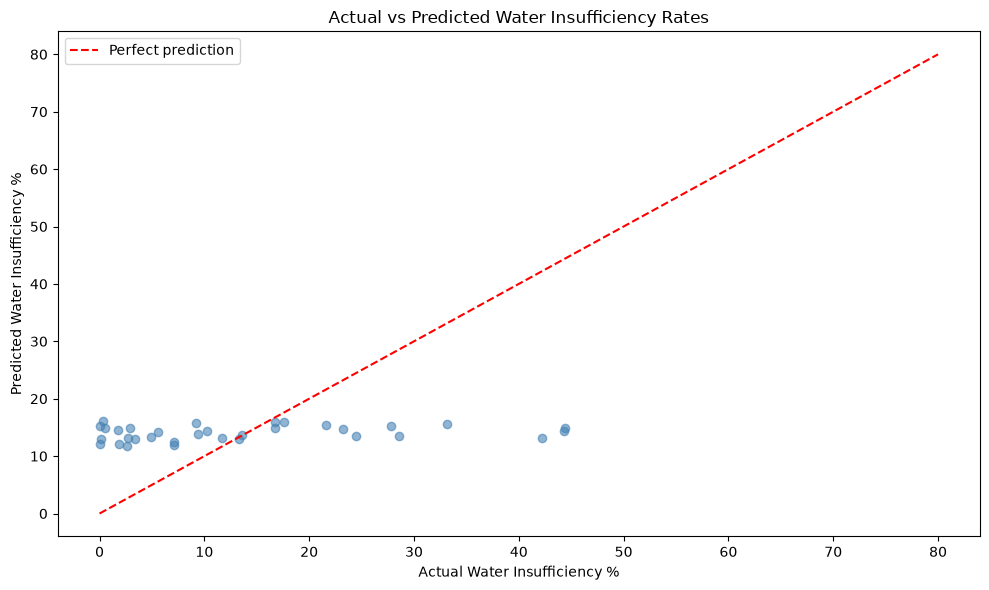

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([0, 80], [0, 80], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Water Insufficiency %')
plt.ylabel('Predicted Water Insufficiency %')
plt.title('Actual vs Predicted Water Insufficiency Rates')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [20]:
# Create a lookup for country codes
country_lookup = dict(zip(
    df_all['country'], 
    df_all['country_code']
))

# Predict for specific countries in 2027, 2028, 2030
future_countries = ['Ethiopia', 'Burundi', 'Malawi', 'Kenya', 'Iraq']
future_years     = [2027, 2028, 2030]

print(f"{'Country':<25} {'Year':<8} {'Predicted %'}")
print("-" * 45)

for country in future_countries:
    code = country_lookup.get(country)
    for year in future_years:
        pred = model.predict([[year, code]])[0]
        print(f"{country:<25} {year:<8} {pred:.2f}%")

Country                   Year     Predicted %
---------------------------------------------
Ethiopia                  2027     17.97%
Ethiopia                  2028     19.17%
Ethiopia                  2030     21.58%
Burundi                   2027     18.32%
Burundi                   2028     19.52%
Burundi                   2030     21.93%
Malawi                    2027     17.44%
Malawi                    2028     18.65%
Malawi                    2030     21.05%
Kenya                     2027     17.60%
Kenya                     2028     18.81%
Kenya                     2030     21.22%
Iraq                      2027     17.71%
Iraq                      2028     18.92%
Iraq                      2030     21.32%


c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\deuca\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

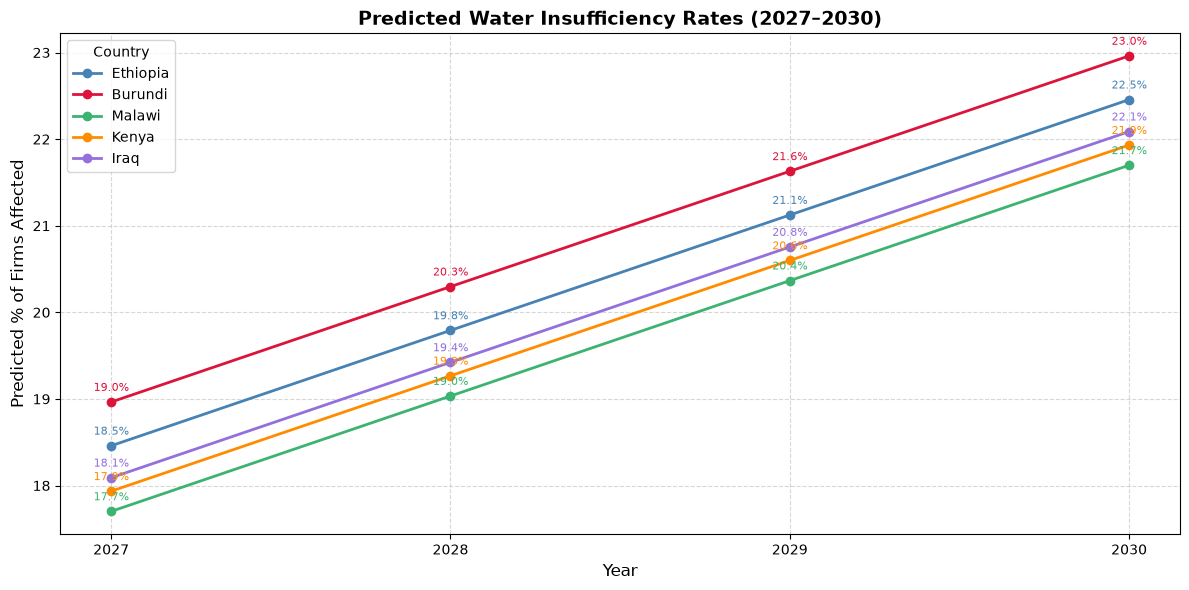

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── Load & clean ──────────────────────────────────────────────
df = pd.read_csv('water1.csv')
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE',
                'COMP_BREAKDOWN_1_LABEL']].copy()
df_clean.columns = ['country', 'year', 'water_pct', 'sector']

df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All'].copy()
df_all['country_code'] = df_all['country'].astype('category').cat.codes

# ── Train model ───────────────────────────────────────────────
X = df_all[['year', 'country_code']]
y = df_all['water_pct']
model = LinearRegression()
model.fit(X, y)

# ── Country lookup ────────────────────────────────────────────
country_lookup = dict(zip(df_all['country'], df_all['country_code']))

# ── Define countries & future years ───────────────────────────
future_countries = ['Ethiopia', 'Burundi', 'Malawi', 'Kenya', 'Iraq']
future_years     = [2027, 2028, 2029, 2030]

# ── Build predictions dataframe ───────────────────────────────
results = []
for country in future_countries:
    code = country_lookup.get(country)
    for year in future_years:
        pred = model.predict([[year, code]])[0]
        results.append({'country': country, 'year': year, 'predicted': pred})

df_future = pd.DataFrame(results)

# ── Plot ──────────────────────────────────────────────────────
colors = ['steelblue', 'crimson', 'mediumseagreen', 'darkorange', 'mediumpurple']

plt.figure(figsize=(12, 6))

for i, country in enumerate(future_countries):
    subset = df_future[df_future['country'] == country]
    plt.plot(subset['year'], subset['predicted'],
             marker='o',
             linewidth=2,
             color=colors[i],
             label=country)
    # Add value labels on each point
    for _, row in subset.iterrows():
        plt.annotate(f"{row['predicted']:.1f}%",
                     xy=(row['year'], row['predicted']),
                     xytext=(0, 8),
                     textcoords='offset points',
                     ha='center',
                     fontsize=8,
                     color=colors[i])

plt.title('Predicted Water Insufficiency Rates (2027–2030)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Predicted % of Firms Affected', fontsize=12)
plt.xticks(future_years)
plt.legend(title='Country', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('future_predictions.png', dpi=150)
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv('water1.csv')
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE',
                'COMP_BREAKDOWN_1_LABEL']].copy()
df_clean.columns = ['country', 'year', 'water_pct', 'sector']

df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All'].copy()

In [23]:
historical_avg = df_all.groupby('year')['water_pct'].mean().reset_index()
historical_avg.columns = ['year', 'avg_water_pct']

print("Historical Global Averages:")
print(historical_avg.to_string(index=False))

Historical Global Averages:
 year  avg_water_pct
 2013      10.459416
 2015       0.160093
 2021       7.087329
 2022      18.514244
 2023      12.416621
 2024       9.485434
 2025      18.303965
 2026      10.720864


In [24]:
X = historical_avg[['year']]
y = historical_avg['avg_water_pct']

model = LinearRegression()
model.fit(X, y)

print(f"Year coefficient: {model.coef_[0]:.4f}")
print(f"Intercept:        {model.intercept_:.4f}")

direction = "INCREASING" if model.coef_[0] > 0 else "DECREASING"
print(f"\nGlobal trend: {direction} by {abs(model.coef_[0]):.2f}% per year")

Year coefficient: 0.6657
Intercept:        -1334.4950

Global trend: INCREASING by 0.67% per year


In [25]:
future_years = pd.DataFrame({'year': [2027, 2028, 2029, 2030]})
future_preds = model.predict(future_years)

df_future = pd.DataFrame({
    'year':          future_years['year'],
    'avg_water_pct': future_preds,
    'type':          'Predicted'
})

print("Future Predictions:")
print(df_future.to_string(index=False))

Future Predictions:
 year  avg_water_pct      type
 2027      14.804267 Predicted
 2028      15.469930 Predicted
 2029      16.135593 Predicted
 2030      16.801257 Predicted


In [26]:
historical_avg['type'] = 'Historical'

df_combined = pd.concat([historical_avg, df_future], ignore_index=True)

print("Full Forecast Table (Historical + Predicted):")
print(df_combined.to_string(index=False))

Full Forecast Table (Historical + Predicted):
 year  avg_water_pct       type
 2013      10.459416 Historical
 2015       0.160093 Historical
 2021       7.087329 Historical
 2022      18.514244 Historical
 2023      12.416621 Historical
 2024       9.485434 Historical
 2025      18.303965 Historical
 2026      10.720864 Historical
 2027      14.804267  Predicted
 2028      15.469930  Predicted
 2029      16.135593  Predicted
 2030      16.801257  Predicted


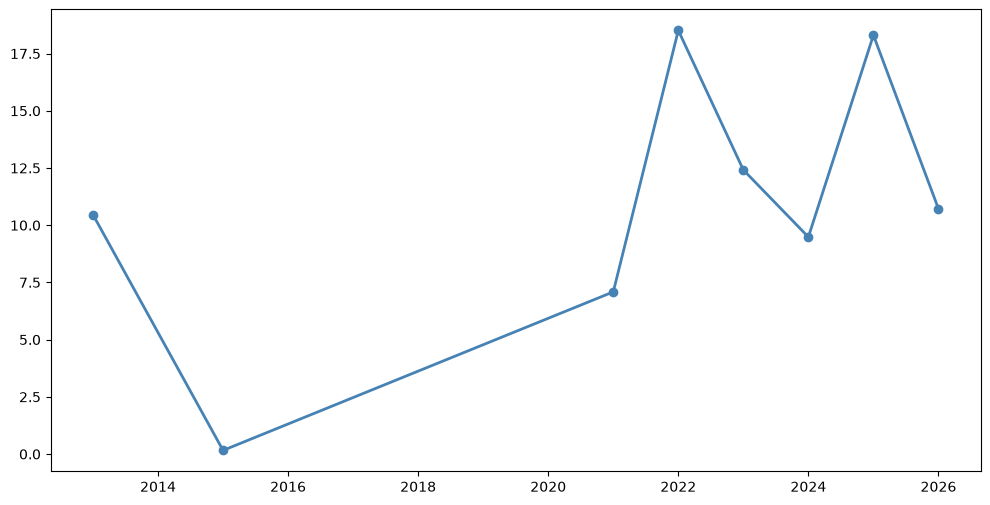

In [27]:
plt.figure(figsize=(12, 6))

hist = df_combined[df_combined['type'] == 'Historical']
plt.plot(hist['year'], hist['avg_water_pct'],
         marker='o',
         color='steelblue',
         linewidth=2,
         label='Historical Average')

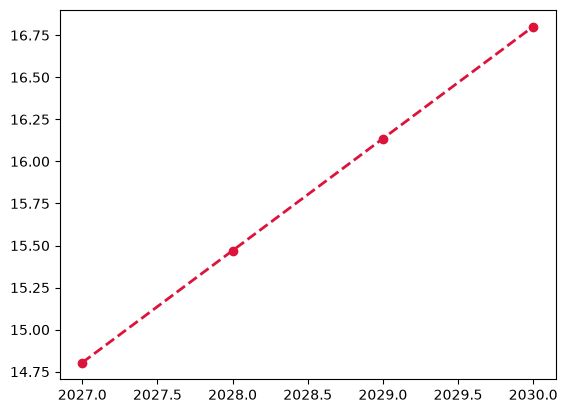

In [28]:
pred = df_combined[df_combined['type'] == 'Predicted']
plt.plot(pred['year'], pred['avg_water_pct'],
         marker='o',
         color='crimson',
         linewidth=2,
         linestyle='--',
         label='Predicted Average')

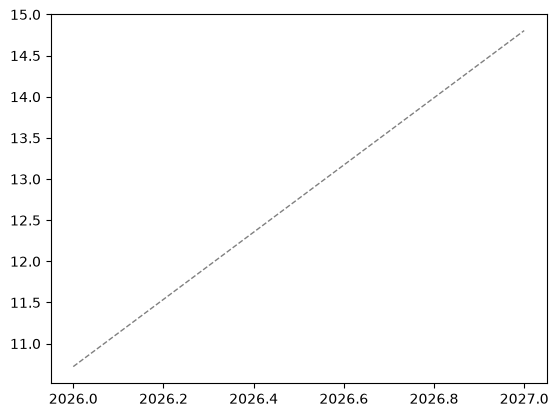

In [29]:
last_hist  = hist.iloc[-1]
first_pred = pred.iloc[0]

plt.plot([last_hist['year'], first_pred['year']],
         [last_hist['avg_water_pct'], first_pred['avg_water_pct']],
         color='gray',
         linestyle='--',
         linewidth=1)

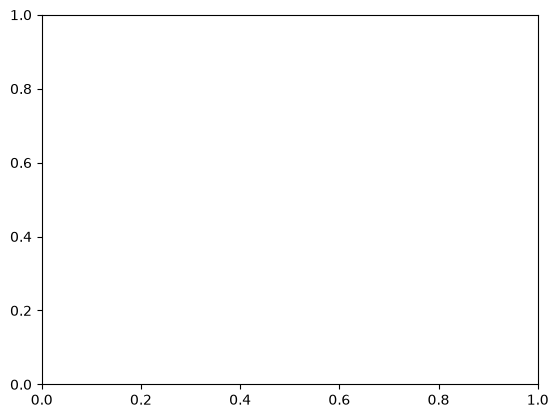

In [30]:
for _, row in df_combined.iterrows():
    color = 'steelblue' if row['type'] == 'Historical' else 'crimson'
    plt.annotate(f"{row['avg_water_pct']:.1f}%",
                 xy=(row['year'], row['avg_water_pct']),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=8,
                 color=color)

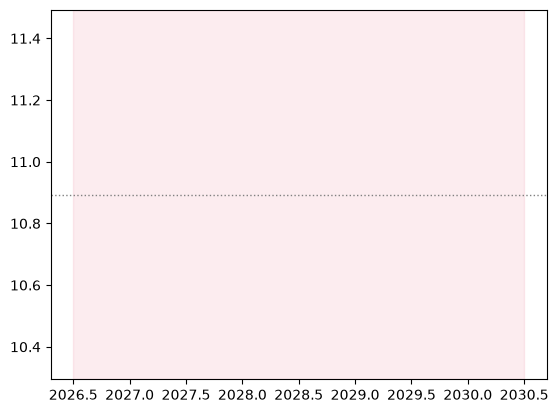

In [31]:
plt.axvspan(2026.5, 2030.5,
            alpha=0.08,
            color='crimson',
            label='Forecast Zone')

plt.axhline(y=historical_avg['avg_water_pct'].mean(),
            color='gray',
            linestyle=':',
            linewidth=1,
            label=f"Overall Mean ({historical_avg['avg_water_pct'].mean():.1f}%)")

C:\Users\deuca\AppData\Local\Temp\ipykernel_23040\3653777045.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


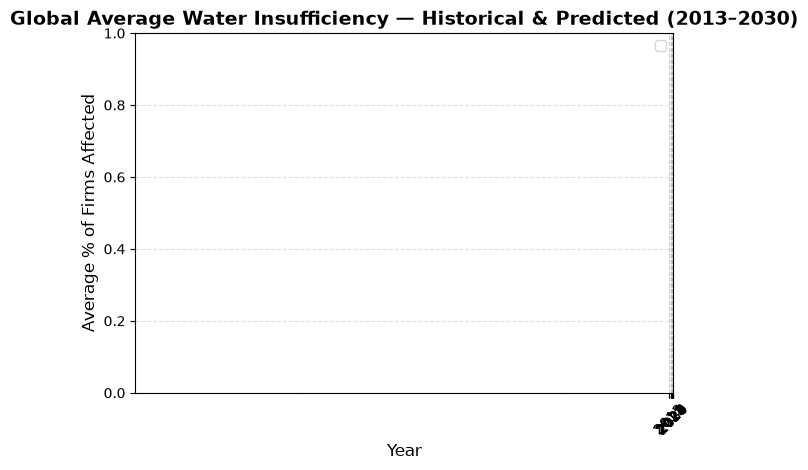

In [32]:
plt.title('Global Average Water Insufficiency — Historical & Predicted (2013–2030)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average % of Firms Affected', fontsize=12)
plt.xticks(df_combined['year'].unique(), rotation=45)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('global_avg_prediction.png', dpi=150)
plt.show()

In [33]:
# Fix 1 — convert year to integer
df_all['year'] = df_all['year'].astype(int)

# Fix 2 — convert decimals to percentages
df_all['water_pct'] = df_all['water_pct'] * 100

Historical Global Averages:
 year  avg_water_pct
 2013    1045.941639
 2015      16.009285
 2021     708.732939
 2022    1851.424426
 2023    1241.662096
 2024     948.543426
 2025    1830.396466
 2026    1072.086429

Global trend: INCREASING by 66.57% per year


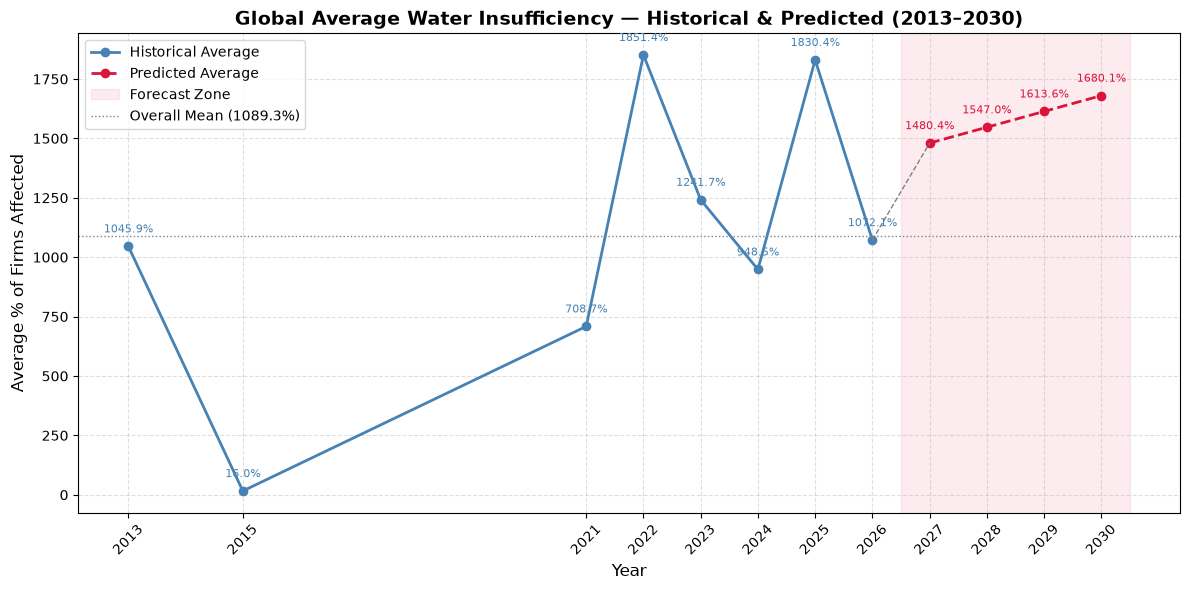

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# ── Step 1 — Load & clean ─────────────────────────────────────
df = pd.read_csv('water1.csv')
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE',
                'COMP_BREAKDOWN_1_LABEL']].copy()
df_clean.columns = ['country', 'year', 'water_pct', 'sector']

df_all = df_clean[df_clean['sector'] == 'Sector: Manufacturing - All'].copy()

# ── THE TWO FIXES ─────────────────────────────────────────────
df_all['year']      = df_all['year'].astype(int)      # Fix 1
df_all['water_pct'] = df_all['water_pct'] * 100       # Fix 2

# ── Step 2 — Historical global average ───────────────────────
historical_avg = df_all.groupby('year')['water_pct'].mean().reset_index()
historical_avg.columns = ['year', 'avg_water_pct']

print("Historical Global Averages:")
print(historical_avg.to_string(index=False))

# ── Step 3 — Train model ──────────────────────────────────────
X = historical_avg[['year']]
y = historical_avg['avg_water_pct']

model = LinearRegression()
model.fit(X, y)

direction = "INCREASING" if model.coef_[0] > 0 else "DECREASING"
print(f"\nGlobal trend: {direction} by {abs(model.coef_[0]):.2f}% per year")

# ── Step 4 — Predict 2027–2030 ────────────────────────────────
future_years = pd.DataFrame({'year': [2027, 2028, 2029, 2030]})
future_preds = model.predict(future_years)

df_future = pd.DataFrame({
    'year':          future_years['year'],
    'avg_water_pct': future_preds,
    'type':          'Predicted'
})

# ── Step 5 — Combine ──────────────────────────────────────────
historical_avg['type'] = 'Historical'
df_combined = pd.concat([historical_avg, df_future], ignore_index=True)

# ── Steps 6–11 — Plot ─────────────────────────────────────────
plt.figure(figsize=(12, 6))

hist = df_combined[df_combined['type'] == 'Historical']
pred = df_combined[df_combined['type'] == 'Predicted']

# Historical line
plt.plot(hist['year'], hist['avg_water_pct'],
         marker='o', color='steelblue', linewidth=2,
         label='Historical Average')

# Predicted line
plt.plot(pred['year'], pred['avg_water_pct'],
         marker='o', color='crimson', linewidth=2,
         linestyle='--', label='Predicted Average')

# Connector
last_hist  = hist.iloc[-1]
first_pred = pred.iloc[0]
plt.plot([last_hist['year'], first_pred['year']],
         [last_hist['avg_water_pct'], first_pred['avg_water_pct']],
         color='gray', linestyle='--', linewidth=1)

# Value labels
for _, row in df_combined.iterrows():
    color = 'steelblue' if row['type'] == 'Historical' else 'crimson'
    plt.annotate(f"{row['avg_water_pct']:.1f}%",
                 xy=(row['year'], row['avg_water_pct']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8, color=color)

# Shaded forecast zone
plt.axvspan(2026.5, 2030.5, alpha=0.08, color='crimson',
            label='Forecast Zone')

# Mean reference line
plt.axhline(y=historical_avg['avg_water_pct'].mean(),
            color='gray', linestyle=':', linewidth=1,
            label=f"Overall Mean ({historical_avg['avg_water_pct'].mean():.1f}%)")

plt.title('Global Average Water Insufficiency — Historical & Predicted (2013–2030)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average % of Firms Affected', fontsize=12)
plt.xticks(df_combined['year'].unique(), rotation=45)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('global_avg_prediction.png', dpi=150)
plt.show()